# Exploratory Data Analysis — Cáceres Solar Forecast

Before data preprocessing (outlier removal, imputation, transformations), we first look at:

- Scatter plot matrix to see pairwise feature relationships and feature-target relationships
- Histograms of missingness to check if gaps are systematic or random
- Distribution inspection (mean vs median, heavy tails, skewness)

Also reflecting on data provenance.

**Contents:**
1. Load data & overview
2. Descriptive statistics & distributions
3. Missing data analysis (ESIOS gaps)
4. Scatter plot matrix
5. Correlation heatmap
6. Time series patterns (diurnal & seasonal)
7. Physics validation (clear-sky vs observed, generation vs irradiance)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=0.9)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.max_open_warning'] = 50

## 1. Load data & overview

In [3]:
df = pd.read_csv('data/caceres_assembled_dataset.csv', parse_dates=['datetime_utc'], index_col='datetime_utc')

print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0]} to {df.index[-1]}')
print(f'Frequency: hourly ({len(df)} hours = {len(df)/24:.0f} days = {len(df)/8760:.1f} years)')
print(f'\nColumns ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col:30s}  {df[col].dtype}')

df.head()

Shape: (26304, 16)
Date range: 2022-01-01 00:00:00 to 2024-12-31 23:00:00
Frequency: hourly (26304 hours = 1096 days = 3.0 years)

Columns (16):
  dewpoint_2m_C                   float64
  temperature_2m_C                float64
  surface_pressure_hPa            float64
  total_precip_mm                 float64
  ssrd_wm2                        float64
  strd_wm2                        float64
  solar_zenith                    float64
  solar_azimuth                   float64
  clearsky_ghi                    float64
  clearsky_dni                    float64
  clearsky_dhi                    float64
  hour_sin                        float64
  hour_cos                        float64
  month_sin                       float64
  month_cos                       float64
  pv_generation_gwh               float64


,dewpoint_2m_C,temperature_2m_C,surface_pressure_hPa,total_precip_mm,ssrd_wm2,strd_wm2,solar_zenith,solar_azimuth,clearsky_ghi,clearsky_dni,clearsky_dhi,hour_sin,hour_cos,month_sin,month_cos,pv_generation_gwh
datetime_utc,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,5.992456,9.045897,982.250519,0.0,0.0,278.746754,162.250513,337.709116,0.0,0.0,0.0,0.000000,1.000000,0.0,1.0,0.004
2022-01-01 01:00:00,5.598618,8.583755,981.807873,0.0,0.0,277.033911,162.080471,23.860362,0.0,0.0,0.0,0.258819,0.965926,0.0,1.0,0.006
2022-01-01 02:00:00,5.160802,8.362978,981.683232,0.0,0.0,275.748794,154.528562,55.919130,0.0,0.0,0.0,0.500000,0.866025,0.0,1.0,0.010
2022-01-01 03:00:00,4.679741,8.237647,981.617324,0.0,0.0,274.899749,144.057884,73.805948,0.0,0.0,0.0,0.707107,0.707107,0.0,1.0,0.011
2022-01-01 04:00:00,4.115510,8.022942,981.532890,0.0,0.0,273.865452,132.708566,85.723352,0.0,0.0,0.0,0.866025,0.500000,0.0,1.0,0.007


## 2. Descriptive statistics & distributions

We compute basic descriptive statistics as a starting point.

In [4]:
desc = df.describe().T
desc['median'] = df.median()
desc['skew'] = df.skew()
desc['kurtosis'] = df.kurtosis()
desc['mean_vs_median'] = desc['mean'] - desc['median']

# Highlight: large mean-median gap signals skewness/outliers
desc[['count', 'mean', 'median', 'mean_vs_median', 'std', 'min', 'max', 'skew', 'kurtosis']]

,count,mean,median,mean_vs_median,std,min,max,skew,kurtosis
dewpoint_2m_C,26304.0,8.623530e+00,9.006901e+00,-3.833712e-01,4.439559,-6.155613,19.334168,-3.820246e-01,-0.345353
temperature_2m_C,26304.0,1.740312e+01,1.630712e+01,1.095997e+00,8.268416,-0.165251,42.215170,4.297042e-01,-0.454629
surface_pressure_hPa,26304.0,9.730740e+02,9.723762e+02,6.978119e-01,6.179866,944.797286,993.006751,1.481599e-02,0.897589
total_precip_mm,26304.0,7.282577e-02,0.000000e+00,7.282577e-02,0.281373,-0.000028,5.952539,7.732863e+00,88.537158
ssrd_wm2,26304.0,2.005401e+02,1.076362e+01,1.897765e+02,281.122281,-0.000574,1007.698938,1.242789e+00,0.271183
strd_wm2,26304.0,3.256125e+02,3.292684e+02,-3.655849e+00,40.709212,218.906512,430.304658,-2.104842e-01,-0.702520
solar_zenith,26304.0,8.968228e+01,8.974268e+01,-6.039916e-02,36.303488,17.222320,163.051983,9.189036e-04,-0.937158
solar_azimuth,26304.0,1.811065e+02,1.816393e+02,-5.327836e-01,100.681292,7.511998,354.914704,1.963241e-03,-1.325001
clearsky_ghi,26304.0,2.296265e+02,2.762845e-01,2.293502e+02,306.862402,0.000000,962.228899,1.006229e+00,-0.437860
clearsky_dni,26304.0,3.441245e+02,9.158572e+00,3.349659e+02,384.807339,0.000000,933.479659,3.630500e-01,-1.720302


### 2a. Feature distributions (histograms)

Looking at the shape of each feature's distribution, for later normalization/standardization.

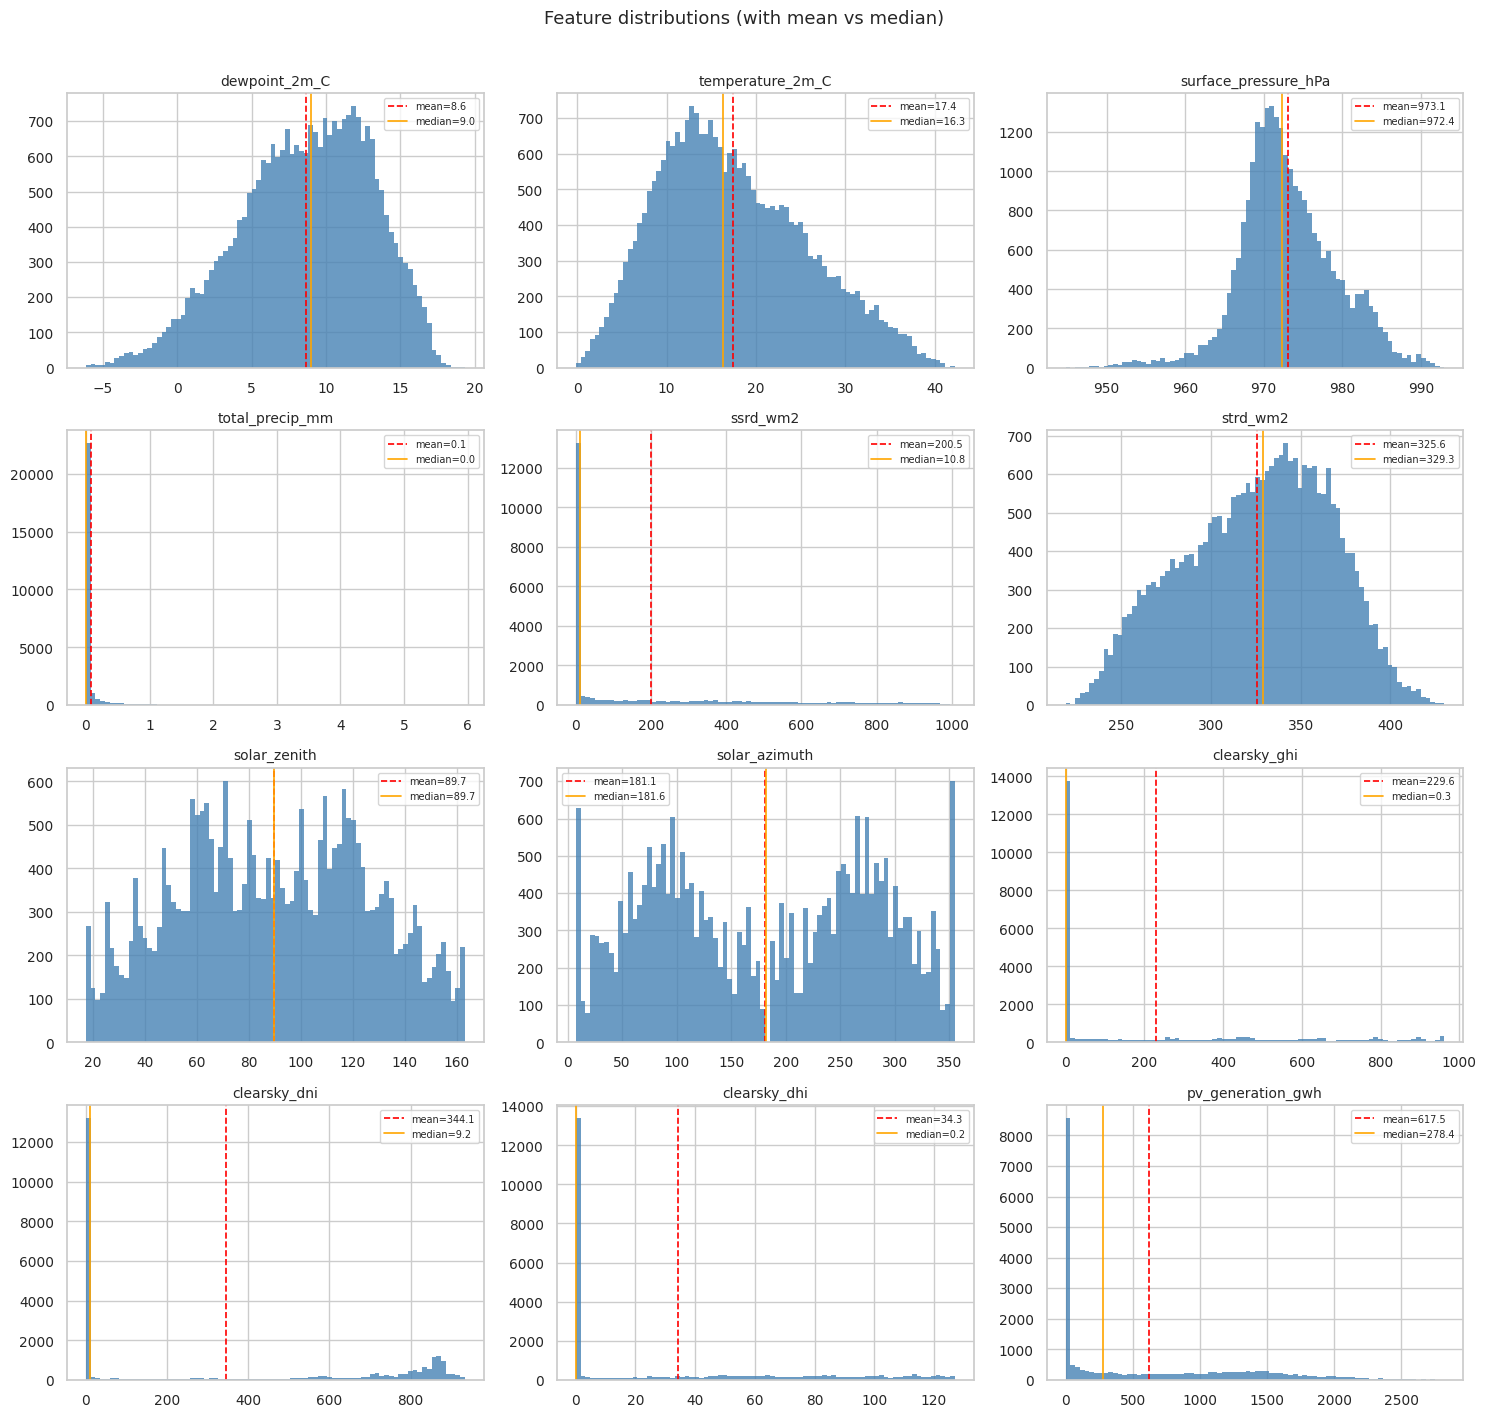

In [5]:
# Exclude cyclical calendar features from distribution plots (they're sin/cos by construction)
feature_cols = [c for c in df.columns if c not in ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    
    # Mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linewidth=1.2, linestyle='--', label=f'mean={mean_val:.1f}')
    ax.axvline(median_val, color='orange', linewidth=1.2, linestyle='-', label=f'median={median_val:.1f}')
    
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

# Hide unused subplot
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions (with mean vs median)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2b. Box plots

As a complement to histograms to spot outliers and compare spread/symmetry across features.

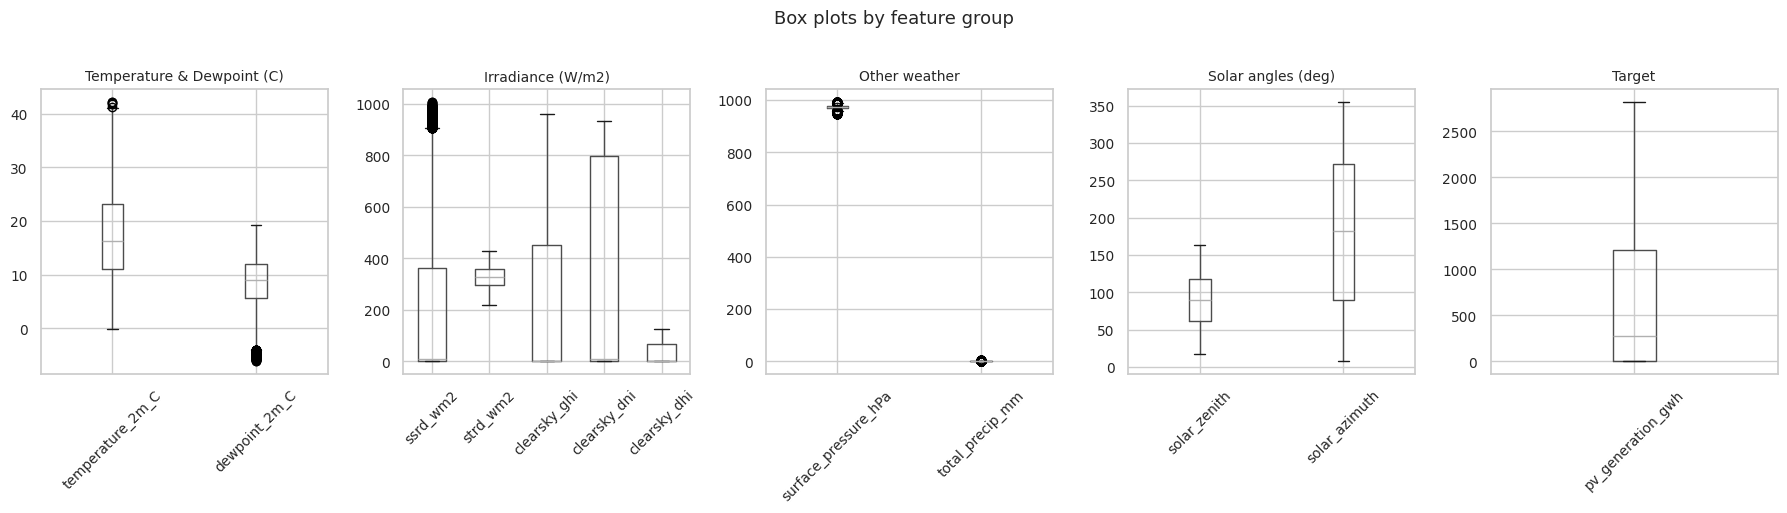

In [6]:
# Separate into groups with comparable scales for readability
groups = {
    'Temperature & Dewpoint (C)': ['temperature_2m_C', 'dewpoint_2m_C'],
    'Irradiance (W/m2)': ['ssrd_wm2', 'strd_wm2', 'clearsky_ghi', 'clearsky_dni', 'clearsky_dhi'],
    'Other weather': ['surface_pressure_hPa', 'total_precip_mm'],
    'Solar angles (deg)': ['solar_zenith', 'solar_azimuth'],
    'Target': ['pv_generation_gwh'],
}

fig, axes = plt.subplots(1, len(groups), figsize=(18, 5))
for ax, (title, cols) in zip(axes, groups.items()):
    df[cols].boxplot(ax=ax, vert=True)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Box plots by feature group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Missing data analysis


In [7]:
is_missing = df['pv_generation_gwh'].isna()
n_missing = is_missing.sum()
n_total = len(df)
print(f'Missing target values: {n_missing}/{n_total} ({n_missing/n_total*100:.1f}%)')

Missing target values: 4802/26304 (18.3%)



We know the ESIOS target has 4,802 missing hours (18.3%). We now plot histograms of missingness against other features to check if the gaps are systematic or random. If missingness correlates with certain conditions (time of day, season, generation level), dropping those rows would bias the dataset.

### 3a. When are the gaps? (temporal pattern)

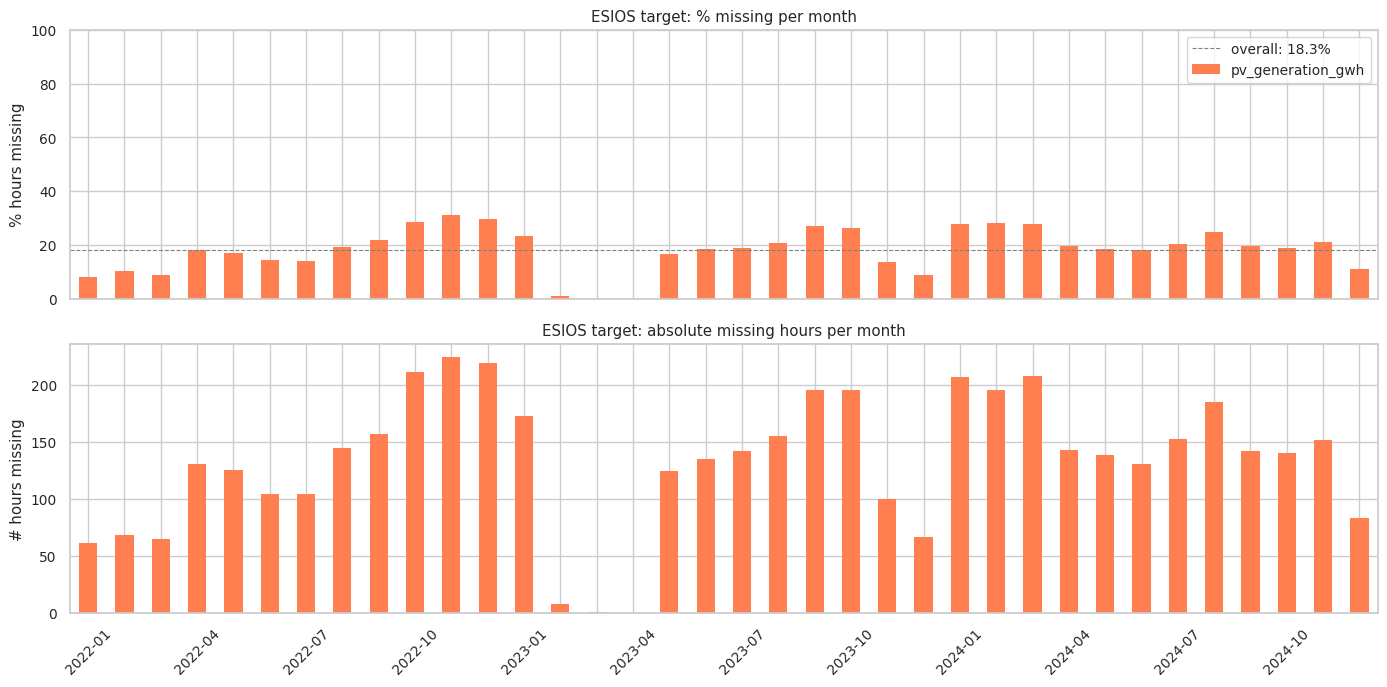

In [8]:
# Missing hours per month
missing_per_month = is_missing.groupby(df.index.to_period('M')).sum()
total_per_month = is_missing.groupby(df.index.to_period('M')).count()
pct_missing_per_month = (missing_per_month / total_per_month * 100)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

pct_missing_per_month.plot(kind='bar', ax=ax1, color='coral', edgecolor='none')
ax1.set_ylabel('% hours missing')
ax1.set_title('ESIOS target: % missing per month')
ax1.set_ylim(0, 100)
ax1.axhline(n_missing/n_total*100, color='grey', linestyle='--', linewidth=0.8, label=f'overall: {n_missing/n_total*100:.1f}%')
ax1.legend()

missing_per_month.plot(kind='bar', ax=ax2, color='coral', edgecolor='none')
ax2.set_ylabel('# hours missing')
ax2.set_title('ESIOS target: absolute missing hours per month')
ax2.set_xlabel('')

# Only show every 3rd x-tick label
for ax in [ax1, ax2]:
    labels = ax.get_xticklabels()
    for i, label in enumerate(labels):
        if i % 3 != 0:
            label.set_visible(False)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

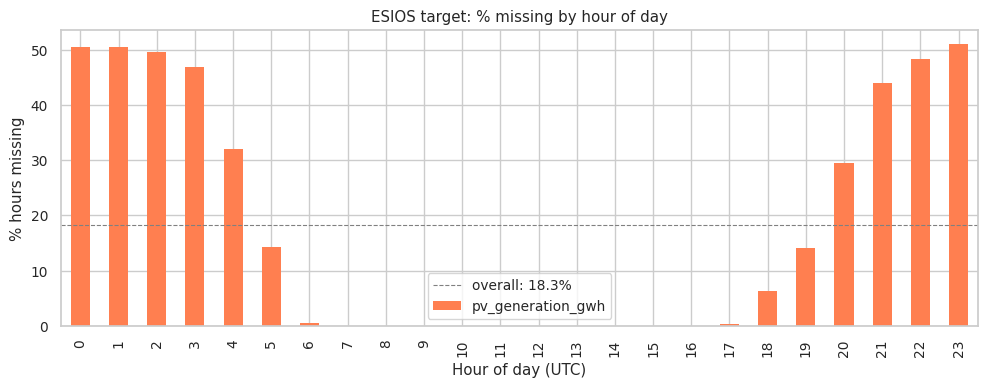

In [9]:
# Missing by hour of day — is there a diurnal pattern?
missing_by_hour = is_missing.groupby(df.index.hour).mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
missing_by_hour.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_ylabel('% hours missing')
ax.set_xlabel('Hour of day (UTC)')
ax.set_title('ESIOS target: % missing by hour of day')
ax.axhline(n_missing/n_total*100, color='grey', linestyle='--', linewidth=0.8, label=f'overall: {n_missing/n_total*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

The histogram above proves very useful.
We learn that the missing hours are basically just overnight: ESIOS probably doesn't include hours where generation is 0 in their dataset. This probably means that later on we can confidently impute those missing instances of pv_generation_gwh with value 0.

### 3b. Missingness vs features (the lecture's histogram test)

If the distribution of a feature looks different for rows with missing target vs rows with present target, then the missingness is **non-random** with respect to that feature.

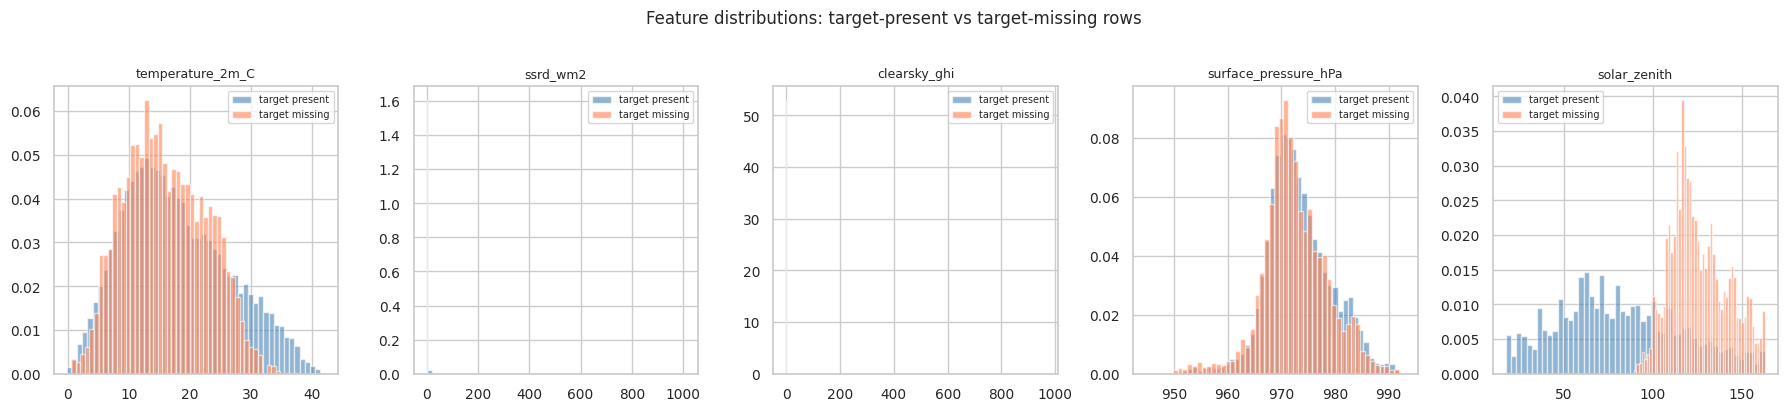

In [10]:
check_cols = ['temperature_2m_C', 'ssrd_wm2', 'clearsky_ghi', 'surface_pressure_hPa', 'solar_zenith']

fig, axes = plt.subplots(1, len(check_cols), figsize=(18, 4))
for ax, col in zip(axes, check_cols):
    ax.hist(df.loc[~is_missing, col], bins=50, alpha=0.6, density=True, label='target present', color='steelblue')
    ax.hist(df.loc[is_missing, col], bins=50, alpha=0.6, density=True, label='target missing', color='coral')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Feature distributions: target-present vs target-missing rows', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Solar zenith makes sense for obvious reasons of it varying between night/day, and our missing data being mostly overnight. Temperature distribution looks similar, I would guess the part on the right of the chart is different for same day/night reason as above; almost all of the missing values are overnight, and 2m temperature during those hours obviously tends to be lower than during daily hours.

### 3c. Visualize the gaps as a timeline

To see if the gaps scattered or clustered in contiguous blocks.

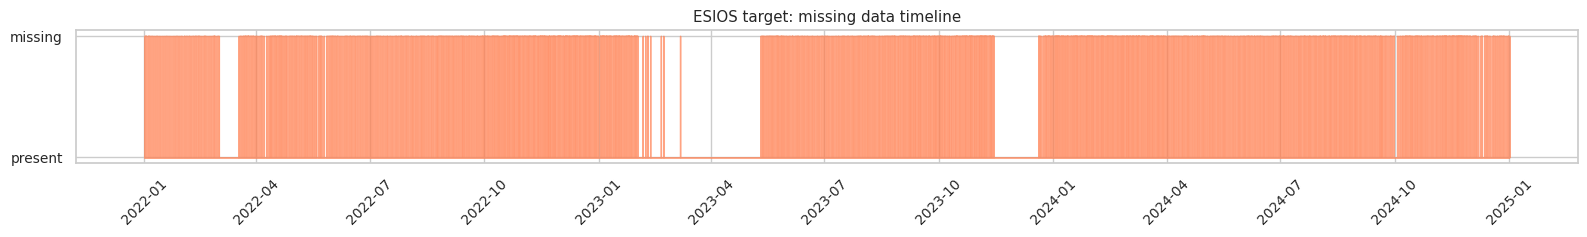

In [11]:
# Show gaps as a binary timeline (1 = missing, 0 = present)
fig, ax = plt.subplots(figsize=(16, 2.5))
ax.fill_between(df.index, 0, is_missing.astype(int), step='mid', color='coral', alpha=0.7)
ax.set_yticks([0, 1])
ax.set_yticklabels(['present', 'missing'])
ax.set_title('ESIOS target: missing data timeline')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

not sure why there are periods of several weeks, like 2023 february to may, where there are almost no missing hours. We'll have to take a look at this but not necessarily a big problem, it just means that energy output was measured overnight as well and/or that for some reason they included it in the dataset against their usual practice.

In [12]:
# Largest contiguous gaps
gap_runs = is_missing.astype(int).diff().fillna(0)
gap_starts = df.index[gap_runs == 1]
gap_ends = df.index[gap_runs == -1]

# Handle edge case: if the series starts or ends with a gap
if is_missing.iloc[0]:
    gap_starts = gap_starts.insert(0, df.index[0])
if is_missing.iloc[-1]:
    gap_ends = gap_ends.append(pd.DatetimeIndex([df.index[-1]]))

gaps = pd.DataFrame({'start': gap_starts[:len(gap_ends)], 'end': gap_ends[:len(gap_starts)]})
gaps['duration_hours'] = (gaps['end'] - gaps['start']).dt.total_seconds() / 3600
gaps = gaps.sort_values('duration_hours', ascending=False)

print(f'Number of gap blocks: {len(gaps)}')
print(f'\nLargest 10 gaps:')
gaps.head(10)

Number of gap blocks: 2039

Largest 10 gaps:


Number of gap blocks: 2039

Largest 10 gaps:


,start,end,duration_hours
564,2022-11-20 17:00:00,2022-11-21 06:00:00,13.0
1153,2023-11-11 19:00:00,2023-11-12 04:00:00,9.0
989,2023-09-07 20:00:00,2023-09-08 05:00:00,9.0
990,2023-09-08 19:00:00,2023-09-09 04:00:00,9.0
569,2022-11-22 17:00:00,2022-11-23 02:00:00,9.0
151,2022-04-21 20:00:00,2022-04-22 05:00:00,9.0
600,2022-12-03 21:00:00,2022-12-04 06:00:00,9.0
1365,2024-02-29 21:00:00,2024-03-01 06:00:00,9.0
461,2022-10-13 21:00:00,2022-10-14 06:00:00,9.0
1808,2024-09-20 19:00:00,2024-09-21 04:00:00,9.0


## 4. Scatter plot matrix

We now produce a scatter plot matrix and include the target value among the features too.

We include only the physically meaningful features (not the cyclical calendar encodings, which are sin/cos by construction and wouldn't reveal anything in a scatter plot).

We use a subset of data points for readability (every 3rd row sampled from non-missing data).

Scatter matrix using 7168 samples


Scatter matrix using 7168 samples


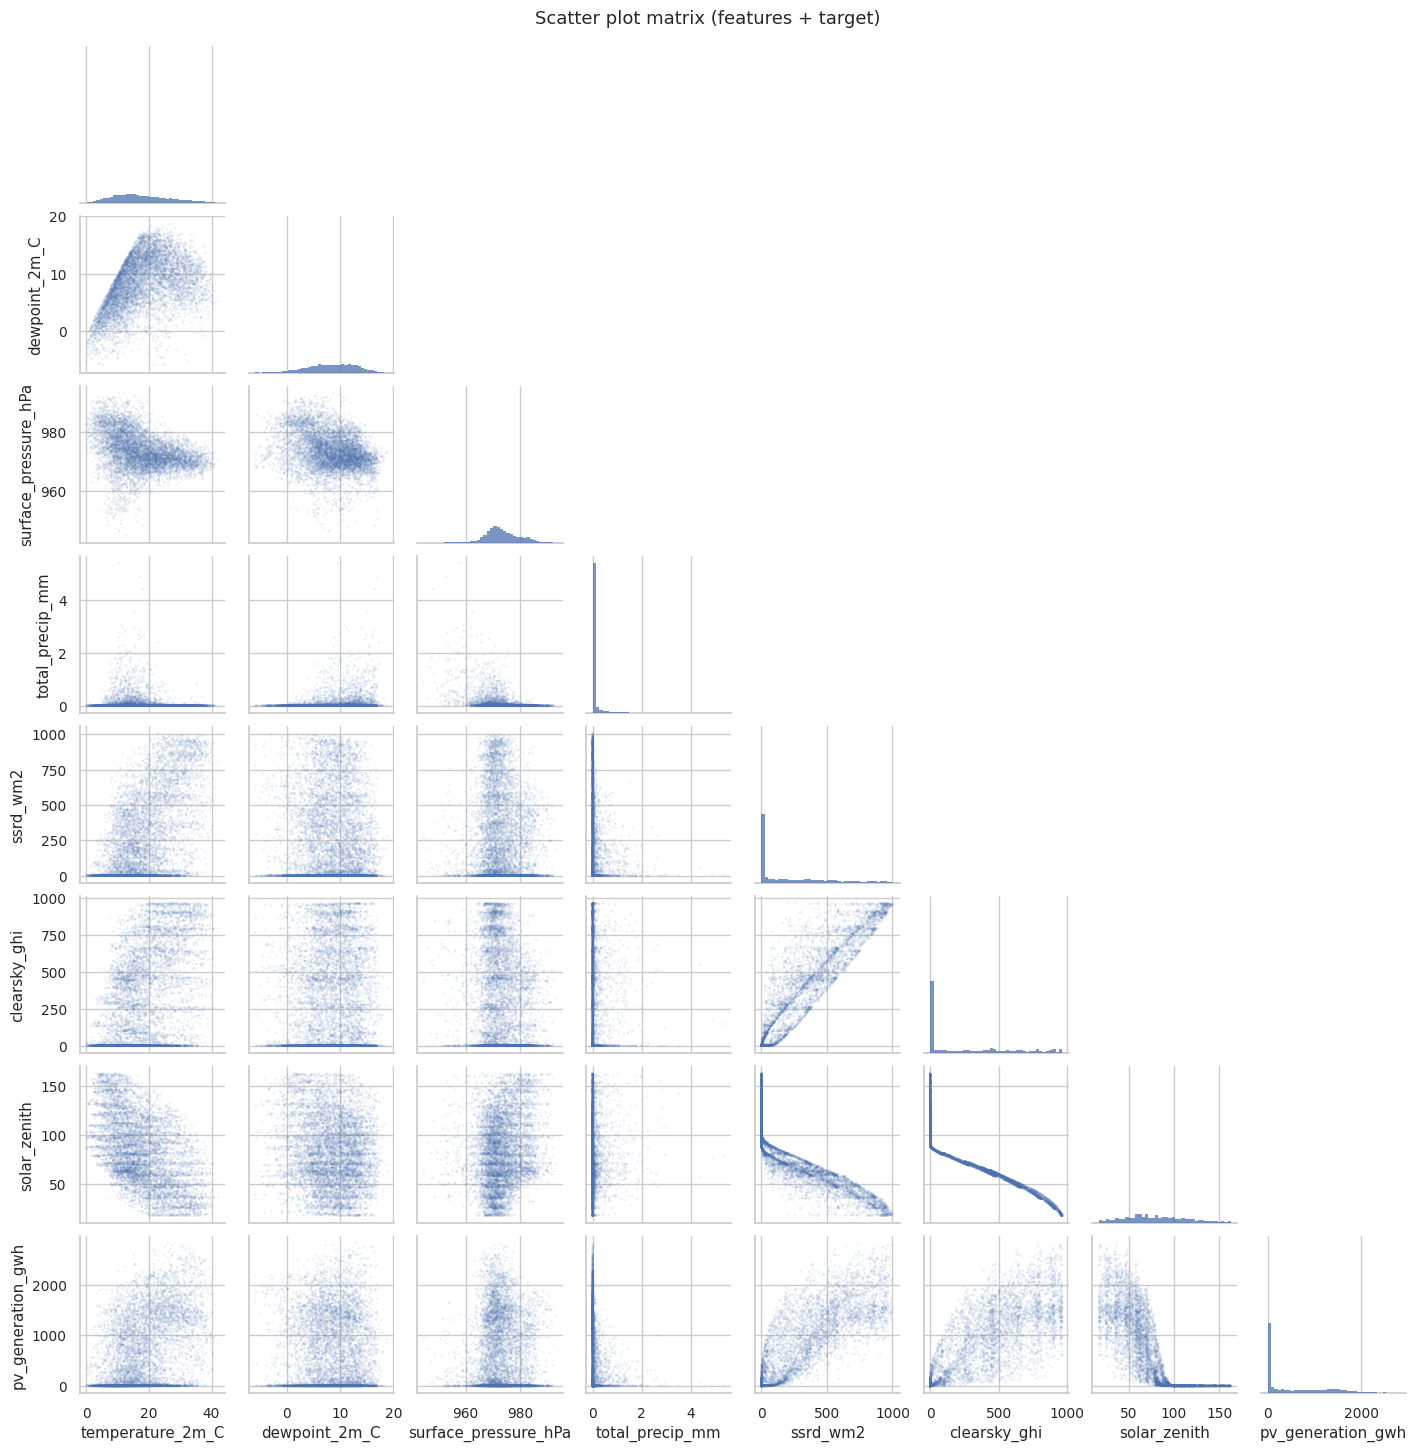

In [13]:
# Features for the scatter matrix (exclude calendar sin/cos — they're deterministic transforms)
scatter_cols = [
    'temperature_2m_C', 'dewpoint_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'clearsky_ghi',
    'solar_zenith', 'pv_generation_gwh'
]

# Subsample for speed (every 3rd row from non-missing data)
df_scatter = df[scatter_cols].dropna().iloc[::3]
print(f'Scatter matrix using {len(df_scatter)} samples')

g = sns.pairplot(
    df_scatter,
    corner=True,
    plot_kws={'alpha': 0.1, 's': 3, 'edgecolor': 'none'},
    diag_kws={'bins': 40, 'edgecolor': 'none'},
    height=1.8,
)
g.figure.suptitle('Scatter plot matrix (features + target)', y=1.01, fontsize=13)
plt.show()

we can already see that surface solar radiation downwards and clearsky global horizontal irradiance appear to be the most correlated (both between themselves and against target). This is useful information.

### 4a. Zoomed-in: Target vs each feature individually

Here we zoom into each feature vs the target for closer inspection.

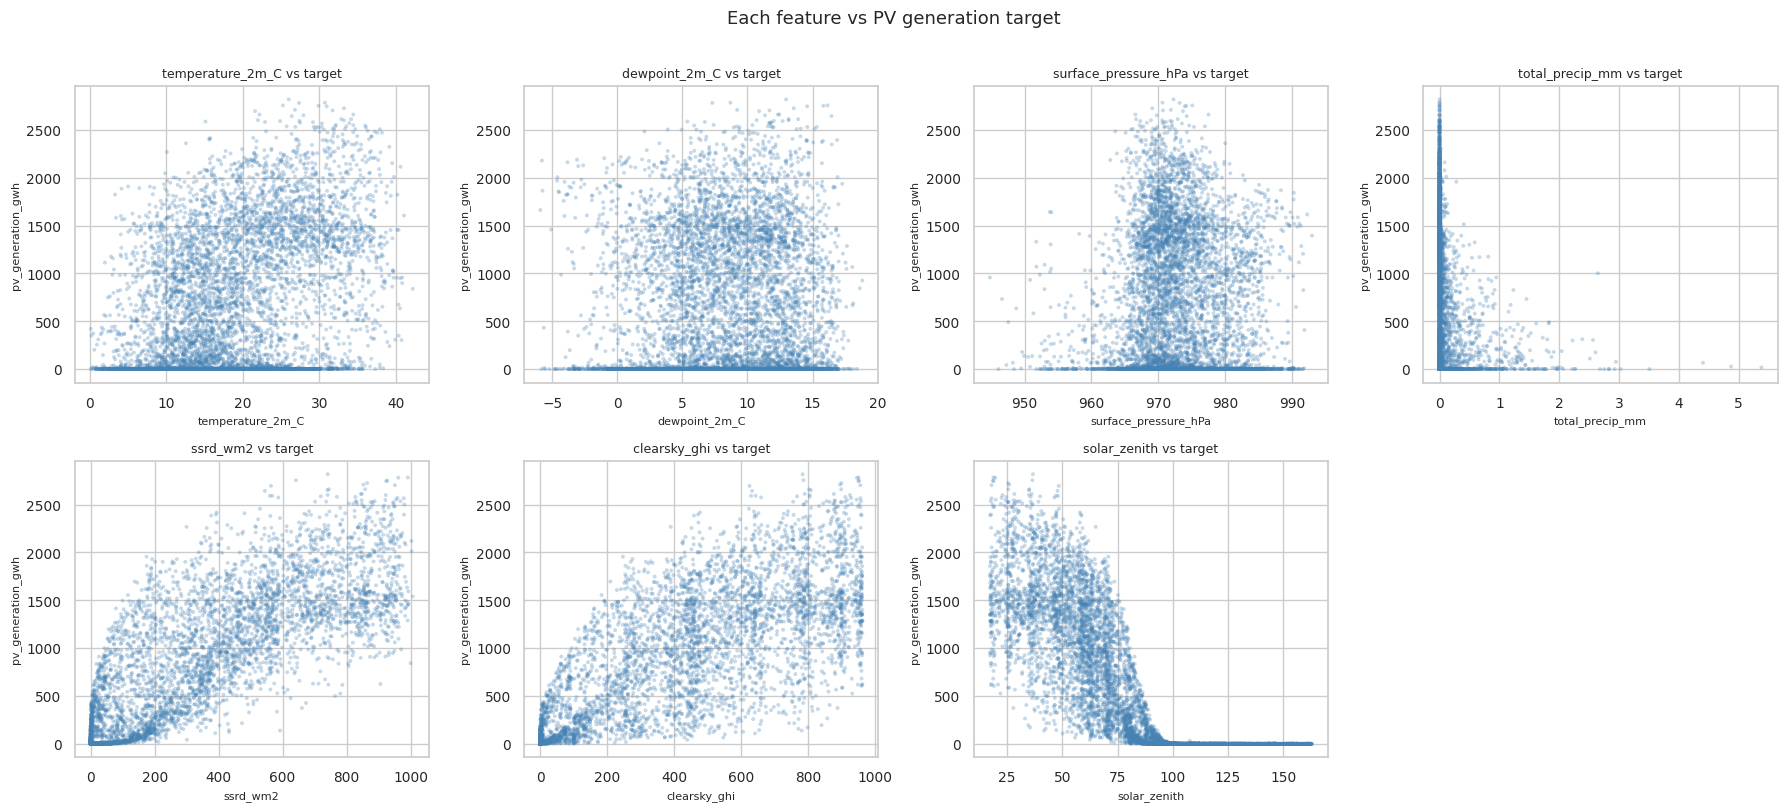

In [14]:
target_col = 'pv_generation_gwh'
feature_vs_target = [c for c in scatter_cols if c != target_col]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

df_plot = df.dropna(subset=[target_col]).iloc[::3]

for i, col in enumerate(feature_vs_target):
    ax = axes[i]
    ax.scatter(df_plot[col], df_plot[target_col], alpha=0.3, s=8, c='steelblue', edgecolor='none')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel(target_col, fontsize=8)
    ax.set_title(f'{col} vs target', fontsize=9)

for j in range(len(feature_vs_target), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Each feature vs PV generation target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation heatmap

Complements the scatter matrix. Highly correlated features signal redundancy — relevant for later feature selection.

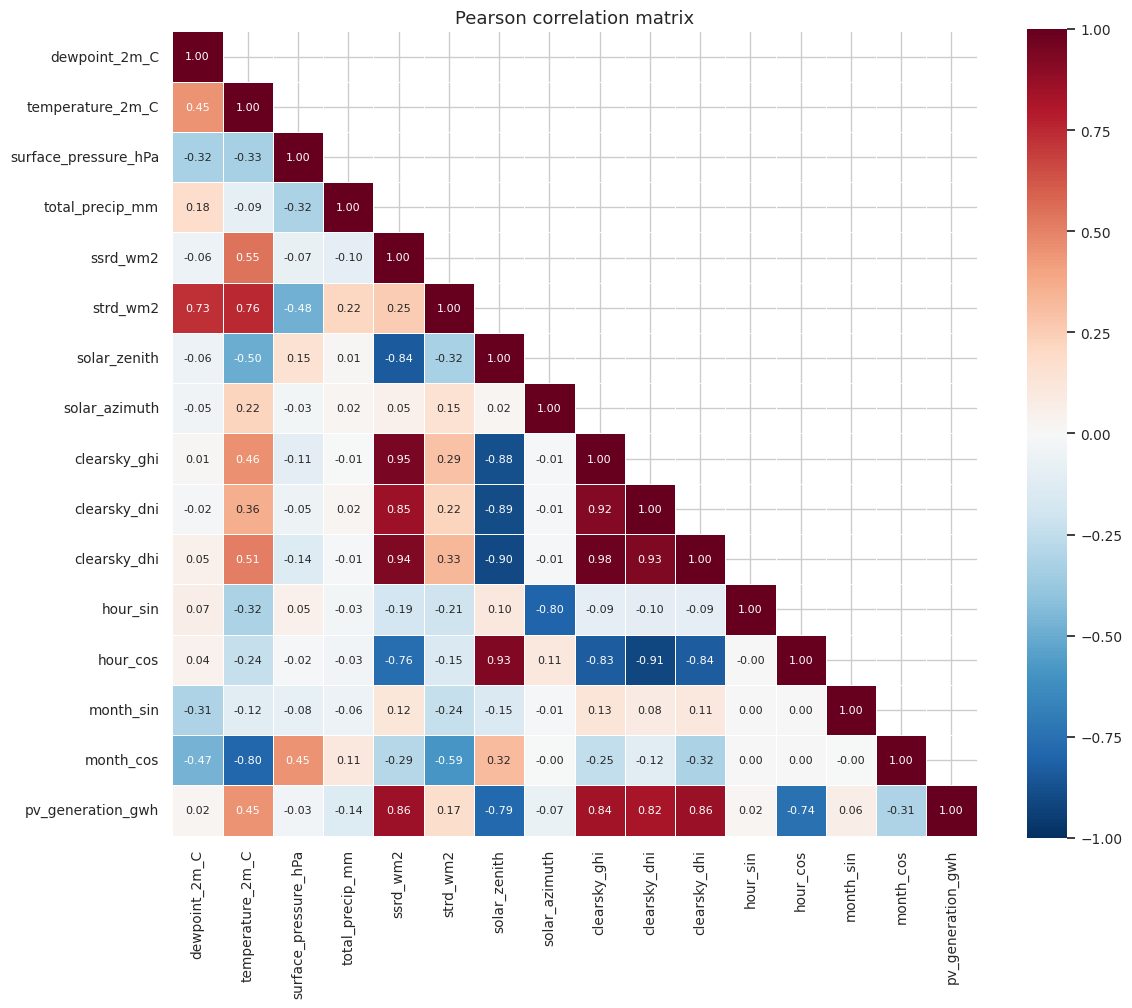

In [15]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Pearson correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Correlations with target, sorted
target_corr = corr['pv_generation_gwh'].drop('pv_generation_gwh').sort_values(key=abs, ascending=False)
print('Feature correlations with PV generation (absolute, descending):')
for feat, r in target_corr.items():
    print(f'  {feat:30s}  r = {r:+.3f}')

Feature correlations with PV generation (absolute, descending):
  clearsky_dhi                    r = +0.864
  ssrd_wm2                        r = +0.859
  clearsky_ghi                    r = +0.842
  clearsky_dni                    r = +0.822
  solar_zenith                    r = -0.786
  hour_cos                        r = -0.744
  temperature_2m_C                r = +0.448
  month_cos                       r = -0.305
  strd_wm2                        r = +0.172
  total_precip_mm                 r = -0.137
  solar_azimuth                   r = -0.070
  month_sin                       r = +0.064
  surface_pressure_hPa            r = -0.032
  dewpoint_2m_C                   r = +0.016
  hour_sin                        r = +0.016


In [17]:
# Correlations between features (excluding target and calendar cycles)
feature_cols_for_corr = [c for c in df.columns if c not in ['pv_generation_gwh', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']]
feature_corr = corr.loc[feature_cols_for_corr, feature_cols_for_corr]

# Find strongest pairwise correlations (excluding diagonal)
corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        feat1 = feature_corr.columns[i]
        feat2 = feature_corr.columns[j]
        r = feature_corr.iloc[i, j]
        corr_pairs.append((feat1, feat2, r))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
print('Strongest feature-feature correlations (absolute, descending):')
for feat1, feat2, r in corr_pairs_sorted[:15]:
    print(f'  {feat1:30s} ↔ {feat2:30s}  r = {r:+.3f}')

Strongest feature-feature correlations (absolute, descending):
  clearsky_ghi                   ↔ clearsky_dhi                    r = +0.978
  ssrd_wm2                       ↔ clearsky_ghi                    r = +0.947
  ssrd_wm2                       ↔ clearsky_dhi                    r = +0.936
  clearsky_dni                   ↔ clearsky_dhi                    r = +0.934
  clearsky_ghi                   ↔ clearsky_dni                    r = +0.918
  solar_zenith                   ↔ clearsky_dhi                    r = -0.900
  solar_zenith                   ↔ clearsky_dni                    r = -0.892
  solar_zenith                   ↔ clearsky_ghi                    r = -0.881
  ssrd_wm2                       ↔ clearsky_dni                    r = +0.852
  ssrd_wm2                       ↔ solar_zenith                    r = -0.840
  temperature_2m_C               ↔ strd_wm2                        r = +0.755
  dewpoint_2m_C                  ↔ strd_wm2                        r = +0.732
 

## 6. Time series patterns

Solar generation follows strong diurnal and seasonal cycles. We now visualize these to confirm the data makes physical sense and reveal any anomalies.

### 6a. Full time series overview

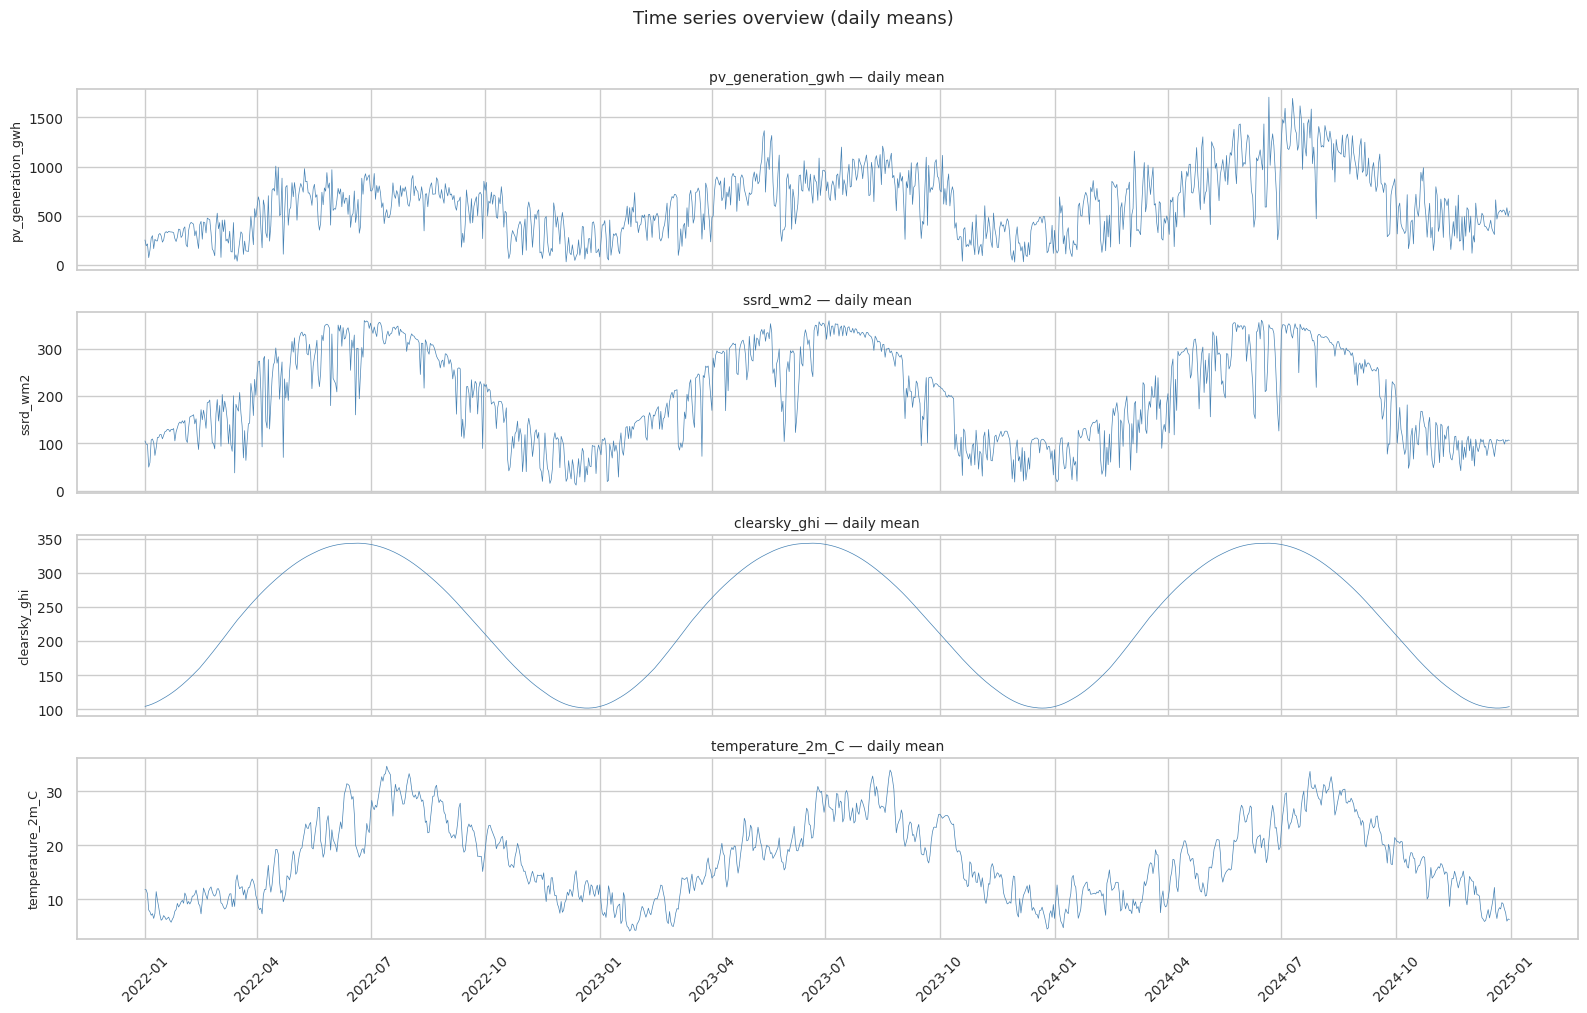

In [18]:
plot_cols = ['pv_generation_gwh', 'ssrd_wm2', 'clearsky_ghi', 'temperature_2m_C']

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(16, 10), sharex=True)

for ax, col in zip(axes, plot_cols):
    # Daily mean for less noisy overview
    daily = df[col].resample('D').mean()
    ax.plot(daily.index, daily.values, linewidth=0.5, color='steelblue')
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(f'{col} — daily mean', fontsize=10)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
fig.suptitle('Time series overview (daily means)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Seems mostly fine. Cyclical for sure; I see a couple of potential anomalies (like around may/june 2024 for ssrd_wm2) that we can look into.

### 6b. Average diurnal profile by season

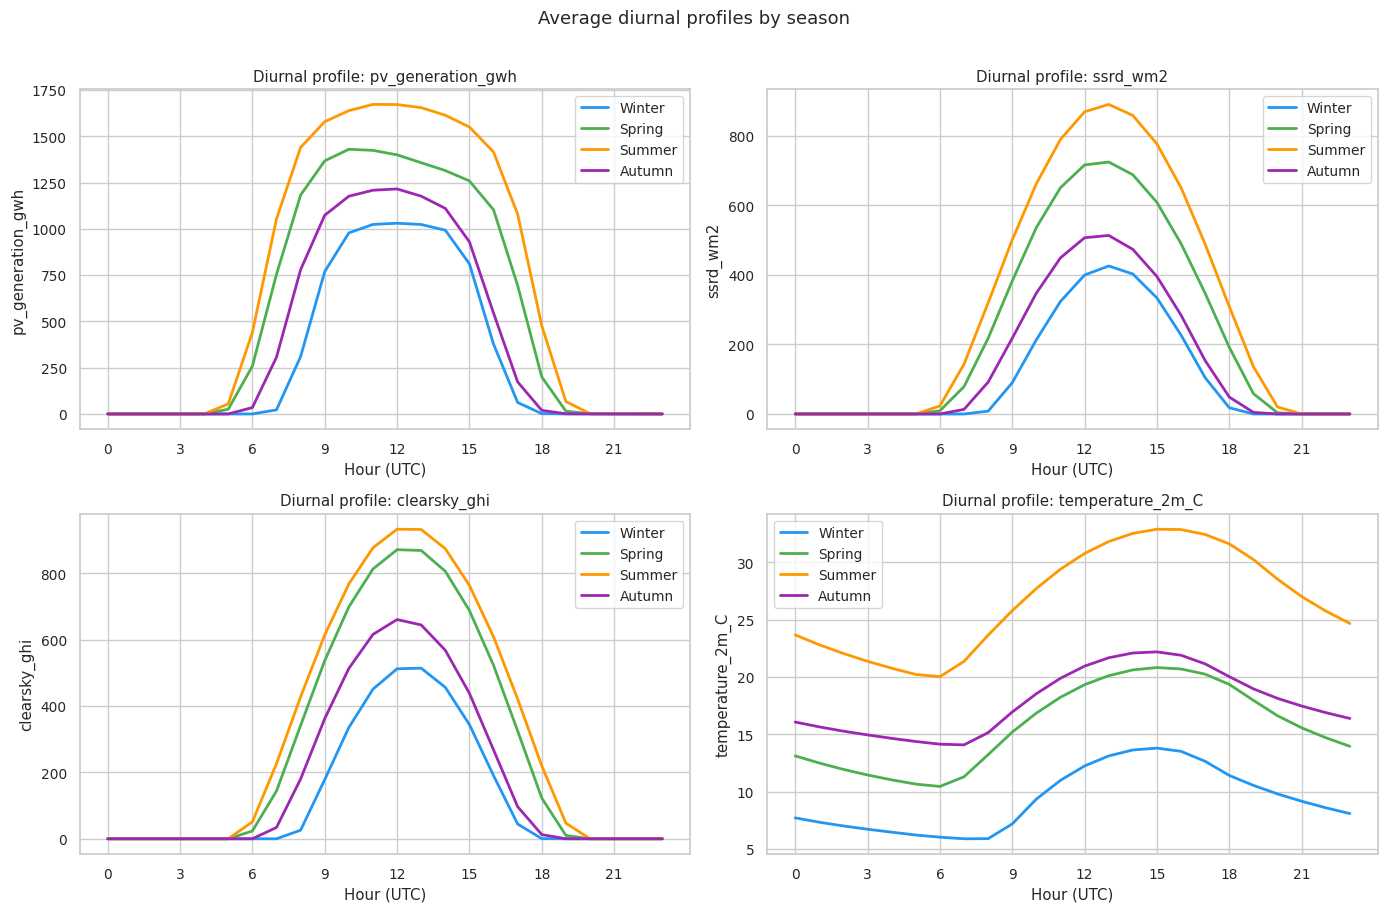

In [19]:
# Assign meteorological seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df.index.month.map(get_season)
df['hour'] = df.index.hour

diurnal_cols = ['pv_generation_gwh', 'ssrd_wm2', 'clearsky_ghi', 'temperature_2m_C']
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
colors = {'Winter': '#2196F3', 'Spring': '#4CAF50', 'Summer': '#FF9800', 'Autumn': '#9C27B0'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, diurnal_cols):
    for season in season_order:
        mask = df['season'] == season
        hourly_mean = df.loc[mask].groupby('hour')[col].mean()
        ax.plot(hourly_mean.index, hourly_mean.values, label=season, color=colors[season], linewidth=2)
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel(col)
    ax.set_title(f'Diurnal profile: {col}')
    ax.legend()
    ax.set_xticks(range(0, 24, 3))

plt.suptitle('Average diurnal profiles by season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6c. Monthly aggregates

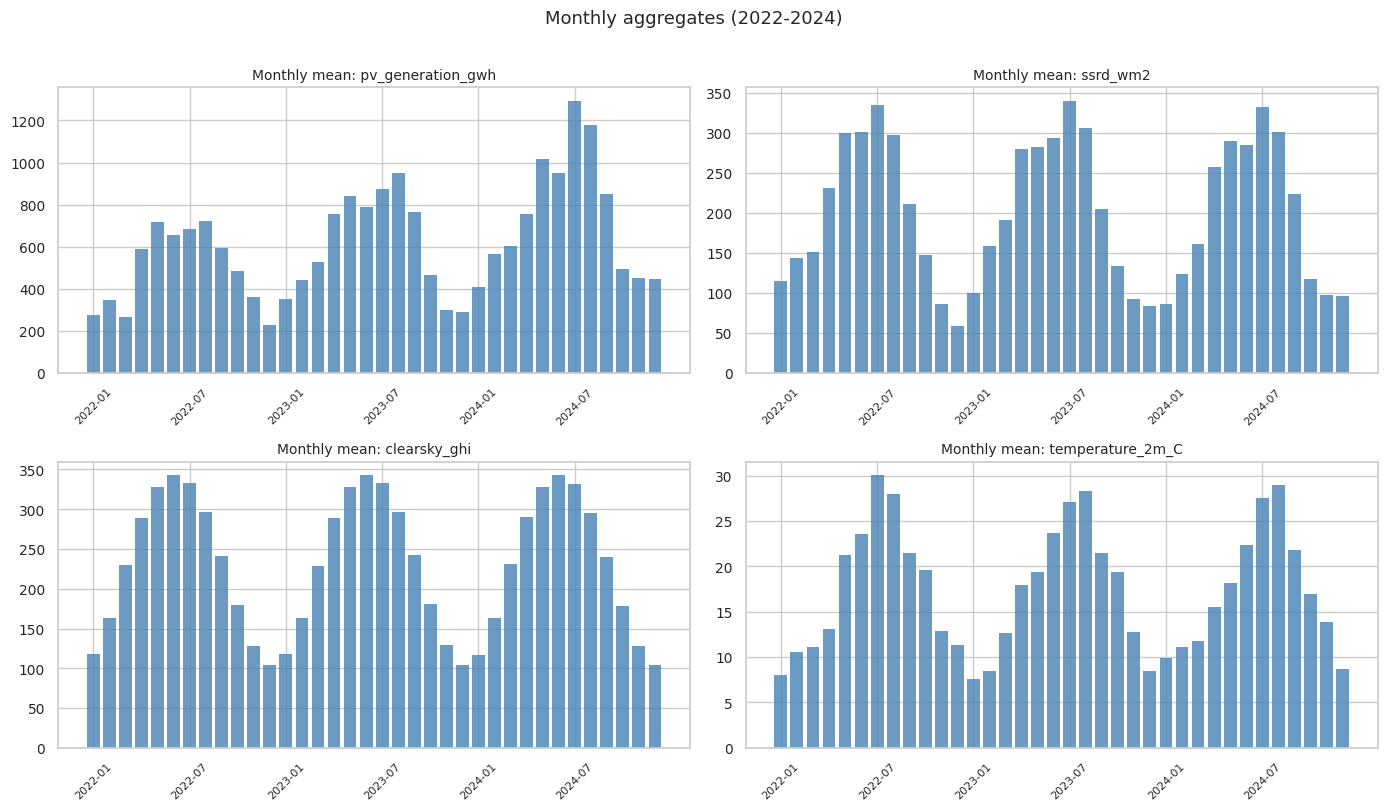

In [20]:
monthly = df[['pv_generation_gwh', 'ssrd_wm2', 'clearsky_ghi', 'temperature_2m_C']].resample('ME').mean()
monthly['month_label'] = monthly.index.strftime('%Y-%m')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, ['pv_generation_gwh', 'ssrd_wm2', 'clearsky_ghi', 'temperature_2m_C']):
    ax.bar(range(len(monthly)), monthly[col], color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'Monthly mean: {col}', fontsize=10)
    ax.set_xticks(range(0, len(monthly), 6))
    ax.set_xticklabels(monthly['month_label'].iloc[::6], rotation=45, fontsize=8)

plt.suptitle('Monthly aggregates (2022-2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Notably there seems to be increasing energy generated from 2022 to 2023 to 2024. Could be due to increase in generation capacity in some plants, since the other factors seem stable/cyclical. Or it could also be something that we overlooked till now: some of these plants may not have existed back in 2022 or were gradually being built during the period we gathered data from, especially considering Spain's solar energy generation capacity has vastly expanded in recent years. Definitely something we need to consider moving forward, and to adjust (if not now, later on when we extend this pipeline to all of Spain). Because right now as explained in data_assembly.ipynb the weather data before being avg for the whole region it's being weighted based on the relative capacity of each plant to the total, but if plant capacity changes or some of them didn't exist in previous years we need to adjust our approach.

## 7. Physics validation

Sanity checks to confirm the data is physically consistent.

### 7a. Clear-sky GHI should upper-bound observed SSRD

The clear-sky model gives theoretical max irradiance (no clouds). ERA5 `ssrd` is actual surface solar radiation. On clear days they should be close; on cloudy days `ssrd` should be well below.

Clear-sky index > 1.05 (ssrd exceeds clearsky): 24.6% of daytime hours
Median kt: 0.880, Mean kt: 0.883


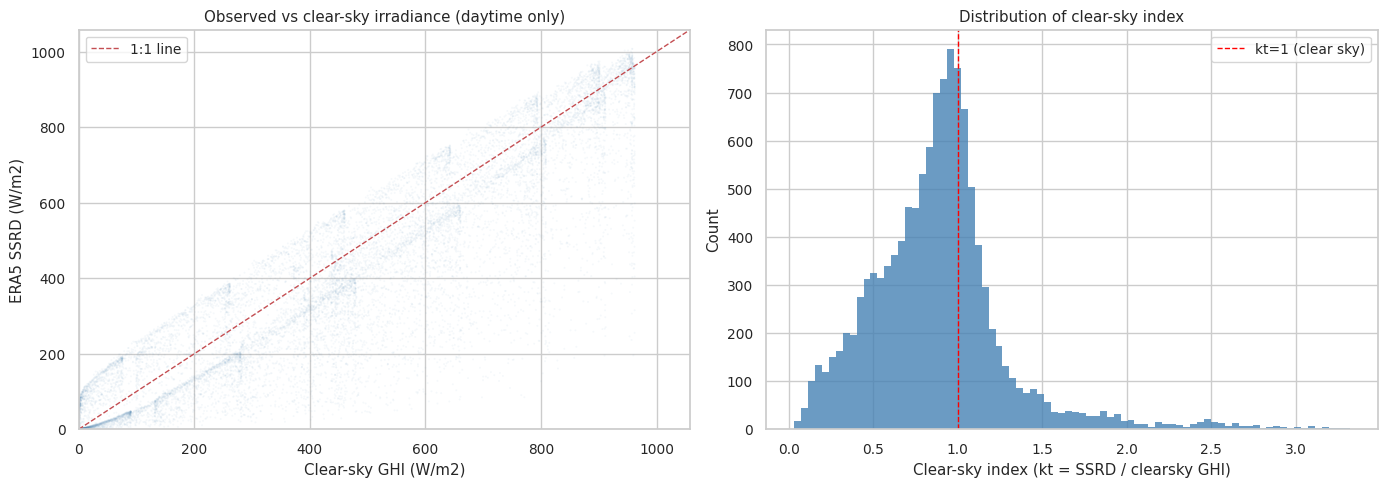

In [21]:
# Only daytime hours (solar zenith < 90)
daytime = df[df['solar_zenith'] < 90].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: observed vs clear-sky
ax1.scatter(daytime['clearsky_ghi'], daytime['ssrd_wm2'], alpha=0.05, s=2, c='steelblue', edgecolor='none')
lim = max(daytime['clearsky_ghi'].max(), daytime['ssrd_wm2'].max()) * 1.05
ax1.plot([0, lim], [0, lim], 'r--', linewidth=1, label='1:1 line')
ax1.set_xlabel('Clear-sky GHI (W/m2)')
ax1.set_ylabel('ERA5 SSRD (W/m2)')
ax1.set_title('Observed vs clear-sky irradiance (daytime only)')
ax1.legend()
ax1.set_xlim(0, lim)
ax1.set_ylim(0, lim)

# Clear-sky index (kt = ssrd / clearsky_ghi)
daytime_bright = daytime[daytime['clearsky_ghi'] > 50]  # avoid division near zero
kt = daytime_bright['ssrd_wm2'] / daytime_bright['clearsky_ghi']
ax2.hist(kt, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax2.axvline(1.0, color='red', linestyle='--', linewidth=1, label='kt=1 (clear sky)')
ax2.set_xlabel('Clear-sky index (kt = SSRD / clearsky GHI)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of clear-sky index')
ax2.legend()

pct_above_1 = (kt > 1.05).sum() / len(kt) * 100
print(f'Clear-sky index > 1.05 (ssrd exceeds clearsky): {pct_above_1:.1f}% of daytime hours')
print(f'Median kt: {kt.median():.3f}, Mean kt: {kt.mean():.3f}')

plt.tight_layout()
plt.show()

Seems consistent/valid.

### 7b. PV generation vs solar irradiance

Generation should track irradiance closely — dropping during cloudy conditions and to near-zero at night.

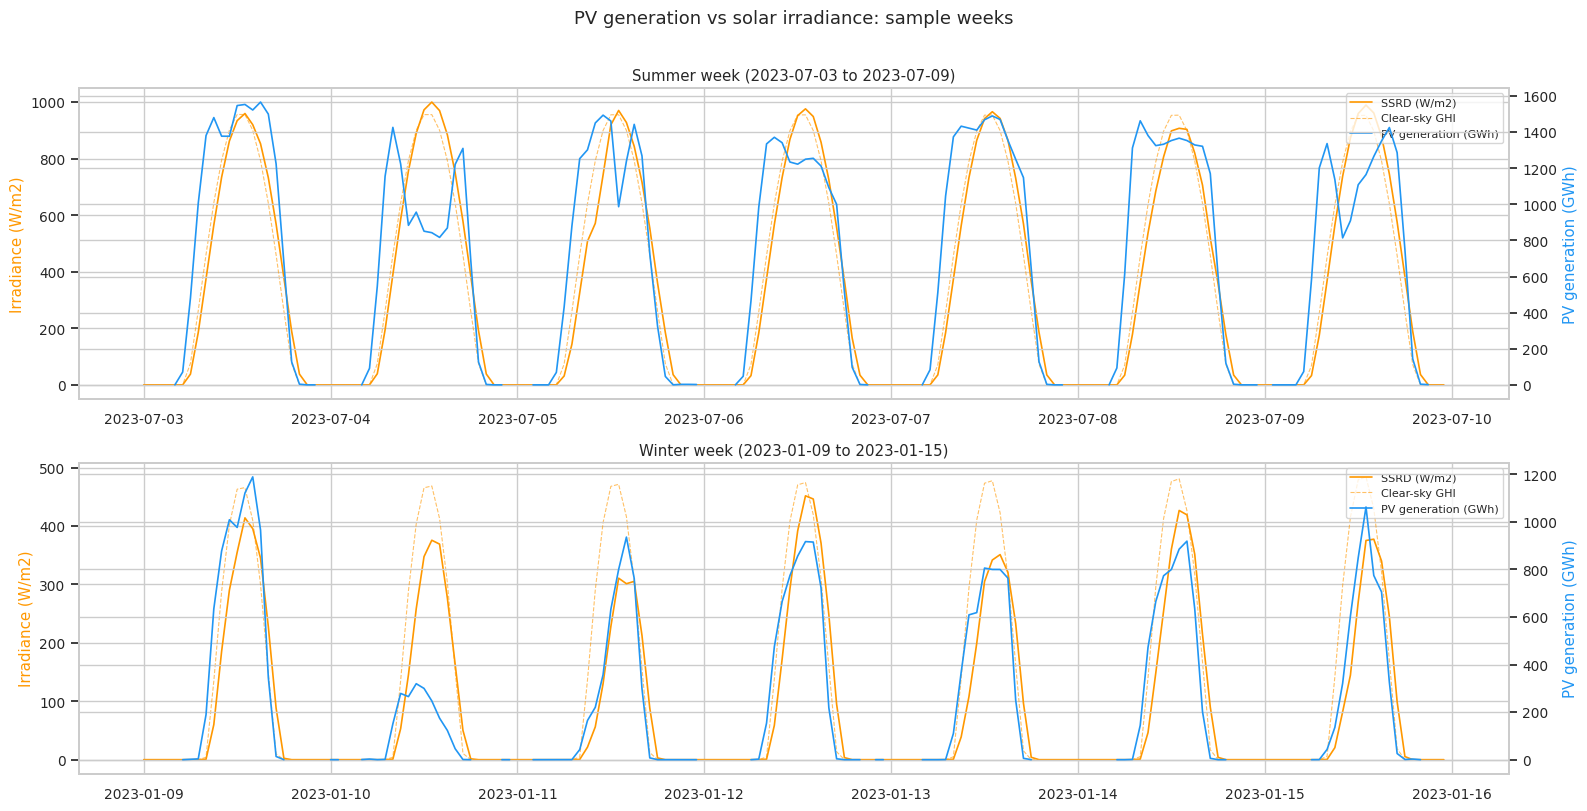

In [22]:
# Pick a clear summer week and a cloudy winter week for comparison
summer_week = df.loc['2023-07-03':'2023-07-09']
winter_week = df.loc['2023-01-09':'2023-01-15']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, week, title in [(ax1, summer_week, 'Summer week (2023-07-03 to 2023-07-09)'),
                         (ax2, winter_week, 'Winter week (2023-01-09 to 2023-01-15)')]:
    ax_twin = ax.twinx()
    ax.plot(week.index, week['ssrd_wm2'], color='#FF9800', linewidth=1.2, label='SSRD (W/m2)')
    ax.plot(week.index, week['clearsky_ghi'], color='#FF9800', linewidth=0.8, linestyle='--', label='Clear-sky GHI', alpha=0.6)
    ax_twin.plot(week.index, week['pv_generation_gwh'], color='#2196F3', linewidth=1.2, label='PV generation (GWh)')
    
    ax.set_ylabel('Irradiance (W/m2)', color='#FF9800')
    ax_twin.set_ylabel('PV generation (GWh)', color='#2196F3')
    ax.set_title(title)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

fig.suptitle('PV generation vs solar irradiance: sample weeks', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Not sure what happened in mid october 2023

### 7c. Night-time generation check

PV generation at night should be near zero. Any substantial night-time values could indicate data quality issues.

Night-time hours (zenith > 95): 12065
Night-time generation stats:
count    7307.000000
mean        0.873284
std         3.584358
min         0.001000
25%         0.001000
50%         0.007000
75%         0.045000
max        52.023000
Name: pv_generation_gwh, dtype: float64


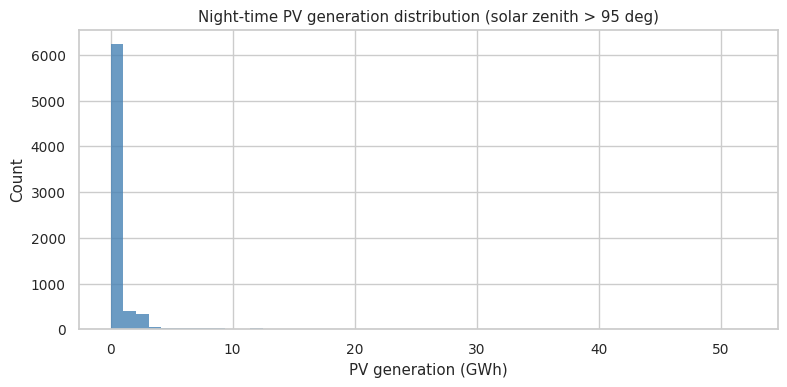

In [26]:
nighttime = df[df['solar_zenith'] > 95].copy()  # well past sunset
night_gen = nighttime['pv_generation_gwh'].dropna()

print(f'Night-time hours (zenith > 95): {len(nighttime)}')
print(f'Night-time generation stats:')
print(night_gen.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(night_gen, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax.set_xlabel('PV generation (GWh)')
ax.set_ylabel('Count')
ax.set_title('Night-time PV generation distribution (solar zenith > 95 deg)')
plt.tight_layout()
plt.show()

The maximum value of 52 is an outlier we'll have to account for.

### 7d. Temperature effect

PV efficiency decreases with higher temperatures. We therefore plot generation per unit irradiance vs temperature.

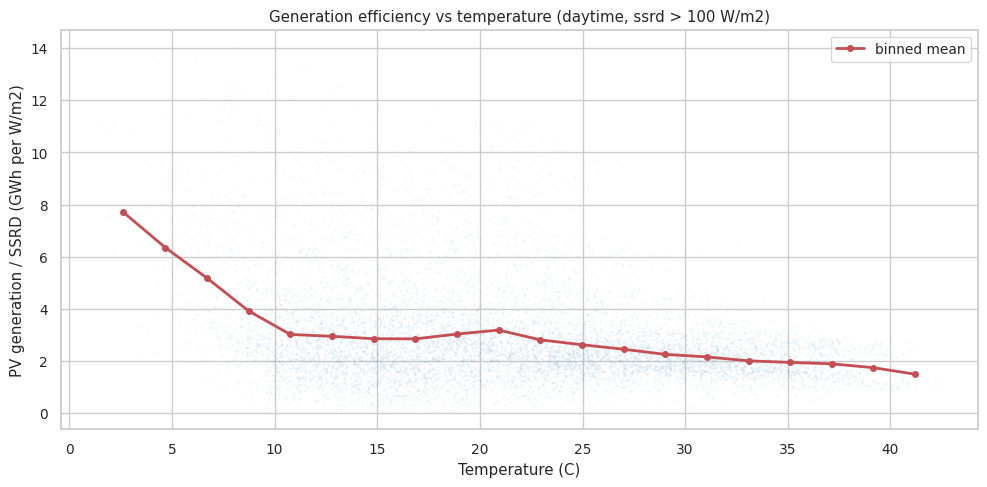

In [24]:
# Only bright daytime hours with meaningful irradiance and generation
bright = df[(df['clearsky_ghi'] > 100) & (df['ssrd_wm2'] > 100) & (df['pv_generation_gwh'].notna())].copy()
bright['gen_per_irradiance'] = bright['pv_generation_gwh'] / bright['ssrd_wm2']

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(bright['temperature_2m_C'], bright['gen_per_irradiance'], alpha=0.05, s=3, c='steelblue', edgecolor='none')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('PV generation / SSRD (GWh per W/m2)')
ax.set_title('Generation efficiency vs temperature (daytime, ssrd > 100 W/m2)')

# Add binned mean
bins = pd.cut(bright['temperature_2m_C'], bins=20)
binned_mean = bright.groupby(bins, observed=True)['gen_per_irradiance'].mean()
bin_centers = [interval.mid for interval in binned_mean.index]
ax.plot(bin_centers, binned_mean.values, 'r-o', markersize=4, linewidth=2, label='binned mean')
ax.legend()

plt.tight_layout()
plt.show()

This further confirms our observations on the apparent validity of the data gathered.

## 8. Key observations & notes for preprocessing

Summary (AI-generated) of observations gathered from this notebook, which you can also find in cells above/below their relative plots:

---

### Data Quality & Missingness

* **Target Missingness:** The target `pv_generation_gwh` has 4,802 missing hours (18.3%). Analysis shows this is **systematic, not random**: the missing data is almost exclusively concentrated overnight.
* **Imputation Strategy:** Since the missing values correspond to hours with zero expected solar generation, they can be confidently imputed with $0$ during preprocessing.
* **Contiguous Gaps:** While most missing data is diurnal, there are some larger, unexplained contiguous blocks (e.g., February–May 2023) where data appears periodically.

### Correlation & Feature Relationships

* **Primary Drivers:** `ssrd_wm2` (Surface Solar Radiation Downwards) and `clearsky_ghi` exhibit the strongest correlation with the target variable and are highly correlated with each other.
* **Multicollinearity:** There is high redundancy between irradiance-related features; this should be considered during feature selection to avoid overfitting.

### Physics Validation

* **Clear-Sky Bound:** The clear-sky model is a reliable upper bound for observed `ssrd`. The clear-sky index ($k_t$) distribution confirms valid atmospheric behavior, with only a small percentage of outliers exceeding $k_t > 1.05$.
* **Night-time Generation:** Most night-time PV generation values are near zero, confirming the data quality is generally high. However, there are minor anomalies (e.g., a maximum value of 52 GWh recorded when solar zenith > 95°) that should be flagged as outliers.
* **Temperature Effects:** The plot of generation efficiency ($\frac{\text{PV Generation}}{\text{SSRD}}$) vs. temperature correctly displays a negative trend, consistent with the physical principle that PV efficiency decreases as temperature rises.

### Time Series & Anomalies

* **Capacity Trends:** There is a noticeable upward trend in total annual energy generation from 2022 to 2024. This is likely attributable to an increase in installed solar capacity in the region rather than purely meteorological factors. This necessitates a careful approach to normalization, as the data reflects a non-stationary generation capacity.
* **Outliers:** Isolated anomalies were identified in the `ssrd_wm2` time series (notably around May/June 2024) and in mid-October 2023, which warrant further inspection before finalizing the training set.

---



In [25]:
# Cleanup temporary columns
df.drop(columns=['season', 'hour'], inplace=True)